custom ML project
Knowledge distilation among Sleep EDF Dataset, to ensure higher quality of sleep stage expectation model from Sleep EEG time-series dataset

local GPU version

In [ ]:
# local runtime - run line: jupyter server --ServerApp.allow_origin='https://colab.research.google.com' --port=8888 --ServerApp.port_retries=0
# connect to the local runtime

# IF cuda=cpu, please c&p following;
# !pip install --target="{LIB_PATH}" --upgrade -q pyhealth litdata mne linear_attention_transformer lightning_utilities ogb rdkit
# !pip install --target="{LIB_PATH}" --upgrade torch==2.5.1+cu121 torchvision==0.20.1+cu121 torchaudio==2.5.1+cu121 --index-url https://download.pytorch.org/whl/cu121

In [ ]:
import sys
import os

LIB_PATH = "C:/Users/junel/sleepEDFproject/package/python3.12/dist-packages/"
if LIB_PATH not in sys.path:
    sys.path.insert(0, LIB_PATH)

import torch

print(f"PyTorch 버전: {torch.__version__}")
print("CUDA version: {}".format(torch.version.cuda))
print(f"사용 가능 GPU 개수: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"장치 이름: {torch.cuda.get_device_name(0)}")
    print(f"메모리 용량: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch 버전: 2.5.1+cu121
CUDA version: 12.1
사용 가능 GPU 개수: 1
장치 이름: NVIDIA GeForce RTX 3060
메모리 용량: 12.88 GB


In [ ]:
import os
import datetime
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.notebook import tqdm  # 주피터 노트북 전용 실시간 진행도 바 라이브러리


In [ ]:
# SleepEDF data -> hdf5 압축: 한 번만 실행

# import h5py
# import numpy as np
# from tqdm.notebook import tqdm

# TEMP_SAVE_DIR = r"C:/Users/junel/sleepEDFproject/pyhealth_temp"
# all_pkl_paths = [os.path.join(TEMP_SAVE_DIR, f) for f in os.listdir(TEMP_SAVE_DIR) if f.endswith(".pkl")]

# H5_PATH = r"C:/sleepEDF_outputs/sleep_dataset.h5"

# # 파일 권한 락 방지를 위한 물리적 선제 삭제
# if os.path.exists(H5_PATH):
#     try:
#         os.remove(H5_PATH)
#         print("🗑️ 기존 h5 파일을 삭제했습니다.")
#     except Exception:
#         print("⚠️ Kernel -> Restart 후 다시 실행해 주세요.")

# if not os.path.exists(os.path.dirname(H5_PATH)):
#     os.makedirs(os.path.dirname(H5_PATH))

# print(f"📦 총 {len(all_pkl_paths)}개의 파일로 가변형 HDF5 아카이브 생성을 시작합니다...")

# with h5py.File(H5_PATH, "w") as f:
#     num_items = len(all_pkl_paths)

#     # 💡 [핵심 해결책] chunks=True와 maxshape 옵션을 주어 가변 리사이징이 가능하도록 선언합니다.
#     sig_ds = f.create_dataset("signals", (num_items, 7, 3000), maxshape=(None, 7, 3000), chunks=True, dtype="float32")
#     lbl_ds = f.create_dataset("labels", (num_items,), maxshape=(None,), chunks=True, dtype="int64")

#     label_map = {'W': 0, '1': 1, '2': 2, '3': 3, '4': 3, 'R': 4}
#     valid_count = 0

#     for idx, pkl_path in enumerate(tqdm(all_pkl_paths, desc="HDF5 최종 정제 중")):
#         try:
#             with open(pkl_path, 'rb') as f_pkl:
#                 actual_data = pickle.load(f_pkl)

#             if isinstance(actual_data, dict):
#                 signal_data = actual_data.get("signal", None)
#                 label_data = str(actual_data.get("label", "W"))
#             else:
#                 signal_data = actual_data
#                 label_data = "W"

#             if signal_data is None:
#                 continue

#             lbl = label_map.get(label_data, 0)
#             sig = np.array(signal_data, dtype=np.float32).reshape(7, 3000)

#             sig_ds[valid_count] = sig
#             lbl_ds[valid_count] = lbl
#             valid_count += 1

#         except Exception:
#             continue

#     # 💡 이제 데이터셋이 Chunked 구조이므로 리사이징 연산이 정상 작동합니다.
#     if valid_count > 0:
#         sig_ds.resize((valid_count, 7, 3000))
#         lbl_ds.resize((valid_count,))

# print(f"\n✨ [최종 정제 완료] 총 {valid_count}개의 데이터가 고속 HDF5 파일로 빌드되었습니다!")

In [ ]:
import torch
import torch.nn as nn

class PurePyTorchTransformer(nn.Module):
    def __init__(self, num_classes=5, embedding_dim=128, nhead=8, num_layers=4, dropout=0.2):
        super(PurePyTorchTransformer, self).__init__()

        # 💡 [구조 정의] 입력 데이터의 마지막 차원(3000차원 raw 시그널)을 128차원 임베딩 공간으로 투영
        # nn.Linear는 입력이 3D [Batch, 7, 3000]으로 들어오면 마지막 차원에만 자동으로 작용합니다.
        self.input_projection = nn.Linear(3000, embedding_dim)

        # PyTorch 표준 Transformer Encoder 설정
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=nhead,
            dim_feedforward=embedding_dim * 4,
            dropout=dropout,
            batch_first=True  # 💡 인풋 셰이프 규격을 [Batch, Sequence, Feature]로 받기 위함
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 최종 분류 레이어 (5개 수면 단계 분류)
        self.fc = nn.Linear(embedding_dim, num_classes)

    def forward(self, x): # 📥 들어오는 x의 차원: [batch_size, 7, 3000]

        x = self.input_projection(x) # 1. 3000차원 신호를 128차원으로 선형 투영 -> 차원 변화: [batch_size, 7, 128]

        x = self.transformer_encoder(x) # 2. Transformer 인코더 통과 (시퀀스 길이 7의 맥락 정보 교류) -> 차원 변화: [batch_size, 7, 128]

        x = x.mean(dim=1) # 3. 시퀀스 차원 평균 풀링 (7개 세그먼트 정보를 하나로 압축) -> 차원 변화: [batch_size, 128]

        return self.fc(x) # 4. 최종 분류기 통과 및 로짓 반환 -> 차원 변화: [batch_size, 5]

In [ ]:
import torch
import torch.nn as nn

class SleepStudentCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(SleepStudentCNN, self).__init__()

        # 특징 추출기 (1D CNN 레이어 정렬)
        self.feature_extractor = nn.Sequential(
            # 대형 커널(kernel_size=50)로 로우 시그널의 굵직한 패턴 포착
            # 차원 변화: [Batch, 1, 3000] -> [Batch, 16, 600]
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=50, stride=5, padding=25),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            # 차원 변화: [Batch, 16, 600] -> [Batch, 16, 150]
            nn.MaxPool1d(kernel_size=4),

            # 소형 커널(kernel_size=8)로 세부 특징 포착
            # 차원 변화: [Batch, 16, 150] -> [Batch, 32, 150]
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=8, stride=1, padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            # 차원 변화: [Batch, 32, 150] -> [Batch, 32, 37]
            nn.MaxPool1d(kernel_size=4),
        )

        # 분류기 (Classifier)
        self.classifier = nn.Sequential(

            nn.AdaptiveAvgPool1d(1), # 글로벌 평균 풀링으로 시퀀스 길이에 상관없이 채널당 1개의 대표값 추출. [Batch, 32, 37] -> [Batch, 32, 1]

            nn.Flatten(), # 1차원 벡터로 평탄화. [Batch, 32]

            nn.Linear(32, num_classes) # 최종 수면 단계(5개)로 mapping. [Batch, 5]
        )

    def forward(self, x): # 📥 인입되는 x 차원: [batch_size, 1, 3000] (배치, 채널=1, 뇌파길이=3000)

        x = self.feature_extractor(x) # 1. 1D CNN 특징 추출 -> 차원 결과: [batch_size, 32, 37]

        return self.classifier(x) # 2. 풀링 및 전결합층 통과 -> 최종 분류 로짓 반환: [batch_size, 5]

In [ ]:
import os
import numpy as np
import datetime
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, Dataset, DataLoader, random_split, WeightedRandomSampler
from tqdm.notebook import tqdm

# 하이퍼파라미터 설정

batch_size = 256

print("🚚 [1/4] .pt 파일로부터 메모리 스왑 없이 텐서 구조만 안전하게 연결 중...")
# 💡 weights_only=True로 지정하여 피클 가비지 오버헤드를 원천 차단합니다.
loaded_data = torch.load(r"C:/sleepEDF_outputs/full_dataset.pt", mmap=True, weights_only=True)

# =====================================================================
# 🔥 [핵심 해결책] 전체 41만 개 중 상위 50,000개만 슬라이싱하여 '실제 RAM'에 탑재
# =====================================================================
print("✂️ [2/4] 무작위 디스크 락을 방지하기 위해 50,000개 서브셋을 완전 추출합니다.")
# 전체를 mmap으로 뒤흔들면 디스크가 비명을 지릅니다. 딱 5만 개만 메모리에 찐 데이터로 복사(clone)해 올립니다.
# 이 가벼운 양(약 2.5GB)은 16GB RAM 환경에서도 부드럽게 상주합니다.
subset_size = 50000

signals_subset = loaded_data["signals"][:subset_size].clone().detach()
labels_subset = loaded_data["labels"][:subset_size].clone().detach()

# 완전한 물리 텐서 데이터셋 구축
full_dataset = TensorDataset(signals_subset, labels_subset)
print(f"✅ 메모리 최적화 완료! 고정 RAM 탑재 데이터셋 크기: {len(full_dataset)}개")

# =====================================================================
# 3. 데이터 분할 및 균등 샘플러 구축 (RAM 소모 제로)
# =====================================================================
print("⚖️ [3/4] 서브셋 기준 클래스 분포 균등 분석 진행...")
total_len = len(full_dataset)
train_len = int(0.8 * total_len)
val_len = int(0.1 * total_len)
test_len = total_len - train_len - val_len

train_ds, val_ds, test_ds = random_split(full_dataset, [train_len, val_len, test_len])

# 💡 더 이상 loaded_data 원본 대형 구조체를 건드리지 않고, 추출된 서브셋 정답만 참조
train_indices = train_ds.indices
train_labels = labels_subset[train_indices].numpy()

class_counts = np.bincount(train_labels)
print(f"🔹 균등 분할 대상 클래스별 개수: {class_counts}")

class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]
sample_weights = torch.from_numpy(sample_weights).type(torch.float)

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# =====================================================================
# 4. 데이터로더 최종 장착 (VRAM 부스터 On)
# =====================================================================
# 💡 데이터를 메모리에 쪄두었기 때문에 무작위 셔플링을 해도 디스크 I/O 병목이 발생하지 않습니다.
train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

print("🚀 [4/4] VRAM 부스터 가동 완료! 이제 학습 루프 세션을 켜시면 GPU 가동률이 솟구칩니다.")

🚚 [1/4] .pt 파일로부터 메모리 스왑 없이 텐서 구조만 안전하게 연결 중...
✂️ [2/4] 무작위 디스크 락을 방지하기 위해 50,000개 서브셋을 완전 추출합니다.
✅ 메모리 최적화 완료! 고정 RAM 탑재 데이터셋 크기: 50000개
⚖️ [3/4] 서브셋 기준 클래스 분포 균등 분석 진행...
🔹 균등 분할 대상 클래스별 개수: [27399  1277  6428  2275  2621]
🚀 [4/4] VRAM 부스터 가동 완료! 이제 학습 루프 세션을 켜시면 GPU 가동률이 솟구칩니다.


🔬 [실시간 검증] train_loader가 뱉는 실제 미니 배치의 라벨을 분석합니다...

📊 [첫 번째 미니 배치 결과] 총 256개 샘플 중 분포:
수면 단계 (Class)  실제 들어있는 개수 (Count) 배치 내 실제 비율 (Ratio)
      Class 0                  46             17.97%
      Class 1                  60             23.44%
      Class 2                  38             14.84%
      Class 3                  59             23.05%
      Class 4                  53             20.70%


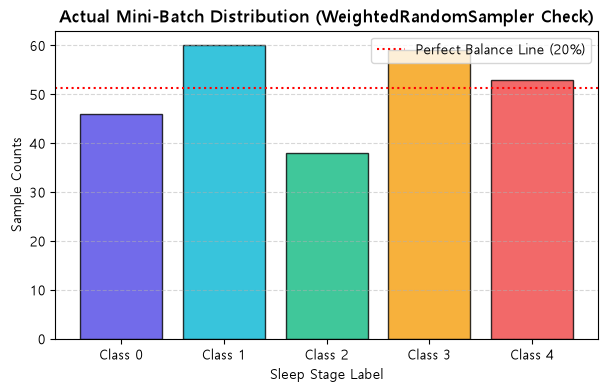

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("🔬 [실시간 검증] train_loader가 뱉는 실제 미니 배치의 라벨을 분석합니다...\n")

# 1. train_loader에서 첫 번째 배치(Batch 1) 딱 하나만 가로채기
for signals, labels in train_loader:
    batch_labels = labels.numpy()
    break # 첫 배치만 빼내고 루프 즉시 종료

# 2. 첫 배치 내에 0~4번 클래스가 각각 몇 개씩 들어있는지 카운트
unique, counts = np.unique(batch_labels, return_counts=True)
batch_distribution = dict(zip(unique, counts))
total_sampled = len(batch_labels)

# 3. 텍스트 보고서 출력
print(f"📊 [첫 번째 미니 배치 결과] 총 {total_sampled}개 샘플 중 분포:")
df = pd.DataFrame({
    "수면 단계 (Class)": [f"Class {c}" for c in range(5)],
    "실제 들어있는 개수 (Count)": [batch_distribution.get(c, 0) for c in range(5)],
    "배치 내 실제 비율 (Ratio)": [f"{(batch_distribution.get(c, 0) / total_sampled) * 100:.2f}%" for c in range(5)]
})
print(df.to_string(index=False))

# 4. 시각화 (바 차트)로 1:1:1:1:1 평형 상태 확인
plt.figure(figsize=(7, 4))
colors = ['#4f46e5', '#06b6d4', '#10b981', '#f59e0b', '#ef4444']
plt.bar(range(5), [batch_distribution.get(c, 0) for c in range(5)], color=colors, edgecolor='black', alpha=0.8)
plt.title("Actual Mini-Batch Distribution (WeightedRandomSampler Check)", fontsize=12, fontweight='bold')
plt.xlabel("Sleep Stage Label")
plt.ylabel("Sample Counts")
plt.xticks(range(5), [f"Class {c}" for c in range(5)])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.axhline(y=total_sampled/5, color='red', linestyle=':', label='Perfect Balance Line (20%)')
plt.legend()
plt.show()

In [ ]:
import os
import datetime
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.notebook import tqdm

# =====================================================================
# 🛠️ 2채널(in_channels=2) 대응 학생 모델 클래스 재정의
# =====================================================================
class SleepStudentCNN(nn.Module):
    def __init__(self, in_channels=2, num_classes=5):
        super(SleepStudentCNN, self).__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=in_channels, out_channels=16, kernel_size=50, stride=5, padding=25),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=15, stride=3, padding=7),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(16)
        )

        self.classifier = nn.Sequential(
            nn.Linear(64 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# =====================================================================
# ⚙️ 통합 하이퍼파라미터 및 날짜 기반 경로 설정
# =====================================================================
TRIAL_NUM = 7          # KD 및 바닐라 공통 실험 번호
alpha = 0.65
temperature = 2.5
epochs = 30
batch_size = 256

current_date = datetime.datetime.now().strftime("%Y%m%d")

BASE_DIR = os.path.join(r"C:/sleepEDF_outputs", current_date)
SAVE_DIR = BASE_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 선언 (이제 정상 작동합니다)
teacher_model = PurePyTorchTransformer().to(device)
student_model = SleepStudentCNN(in_channels=2).to(device)

teacher_model.eval()
for param in teacher_model.parameters():
    param.requires_grad = False

criterion_hard = nn.CrossEntropyLoss()
criterion_soft = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(student_model.parameters(), lr=1e-3, weight_decay=1e-5)

# 💡 [추가] CosineAnnealingLR 스케줄러 장착
# T_max: 학습률이 초기값(1e-3)에서 최소값(eta_min)까지 감소하는 데 걸리는 총 에폭 수
# eta_min: 최대로 줄어들 최소 학습률 설정
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)


best_val_acc = 0.0
history_logs = []

print(f"🚀 [Trial {TRIAL_NUM:02d}] 2채널 KD 학습 시작 ➡️ 저장 경로: {SAVE_DIR}")

for epoch in range(epochs):
    student_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    train_bar = tqdm(train_loader, desc=f"⏳ Epoch [{epoch+1}/{epochs}] KD Train")
    for signals, labels in train_bar:
        signals = signals.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.no_grad():
            teacher_logits = teacher_model(signals)

        student_inputs = signals[:, [0, 3], :] # 2채널 추출
        student_logits = student_model(student_inputs)

        hard_loss = criterion_hard(student_logits, labels)
        soft_loss = criterion_soft(
            F.log_softmax(student_logits / temperature, dim=1),
            F.softmax(teacher_logits / temperature, dim=1)
        ) * (temperature ** 2)

        loss = alpha * hard_loss + (1.0 - alpha) * soft_loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * signals.size(0)
        _, predicted = student_logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        train_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{(correct/total)*100:.1f}%")

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100

    # 검증 단계
    student_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    val_bar = tqdm(val_loader, desc=f"🔬 Epoch [{epoch+1}/{epochs}] KD Val")
    with torch.no_grad():
        for signals, labels in val_bar:
            signals = signals.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            student_inputs = signals[:, [0, 3], :]
            outputs = student_model(student_inputs)
            v_loss = criterion_hard(outputs, labels).item()

            val_loss += v_loss * signals.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

            val_bar.set_postfix(loss=f"{v_loss:.4f}", acc=f"{(val_correct/val_total)*100:.1f}%")

    val_epoch_loss = val_loss / val_total
    val_epoch_acc = (val_correct / val_total) * 100

    #학습률 조정
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    epoch_status = (f"📊 Epoch [{epoch+1}/{epochs}] 요약 -> "
                    f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | "
                    f"Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.2f}% | "
                    f"LR: {current_lr:.6f}")
    print(epoch_status)
    history_logs.append(epoch_status)

    if val_epoch_acc > best_val_acc:
        if best_val_acc > 0.0:
            old_filename = f"student_{current_date}_trial{TRIAL_NUM:02d}_acc{best_val_acc:.2f}.pth"
            old_path = os.path.join(SAVE_DIR, old_filename)
            if os.path.exists(old_path):
                os.remove(old_path)

        best_val_acc = val_epoch_acc
        model_filename = f"student_{current_date}_trial{TRIAL_NUM:02d}_acc{best_val_acc:.2f}.pth"
        model_save_path = os.path.join(SAVE_DIR, model_filename)

        torch.save({
            'trial_num': TRIAL_NUM,
            'epoch': epoch + 1,
            'model_state_dict': student_model.state_dict(),
            'best_acc': best_val_acc,
        }, model_save_path)
        print(f"🎯 [최고 성능 갱신] 가중치 저장 완료 ➡️ {model_save_path}")

🚀 [Trial 07] 2채널 KD 학습 시작 ➡️ 저장 경로: C:/sleepEDF_outputs\20260820


⏳ Epoch [1/30] KD Train:   0%|          | 0/157 [00:00<?, ?it/s]

🔬 Epoch [1/30] KD Val:   0%|          | 0/20 [00:00<?, ?it/s]

📊 Epoch [1/30] 요약 -> Train Loss: 0.9789 Acc: 39.04% | Val Loss: 1.0956 Acc: 74.58% | LR: 0.000997
🎯 [최고 성능 갱신] 가중치 저장 완료 ➡️ C:/sleepEDF_outputs\20260820\student_20260820_trial07_acc74.58.pth


⏳ Epoch [2/30] KD Train:   0%|          | 0/157 [00:00<?, ?it/s]

...

🔬 Epoch [29/30] KD Val:   0%|          | 0/20 [00:00<?, ?it/s]

📊 Epoch [29/30] 요약 -> Train Loss: 0.8107 Acc: 61.74% | Val Loss: 1.0079 Acc: 74.60% | LR: 0.000004


⏳ Epoch [30/30] KD Train:   0%|          | 0/157 [00:00<?, ?it/s]

🔬 Epoch [30/30] KD Val:   0%|          | 0/20 [00:00<?, ?it/s]

📊 Epoch [30/30] 요약 -> Train Loss: 0.8092 Acc: 61.83% | Val Loss: 1.0058 Acc: 74.98% | LR: 0.000001


In [ ]:
# 상단 셀의 TRIAL_NUM과 current_date 변수를 그대로 공유
SAVE_DIR_VANILLA = os.path.join(BASE_DIR, "vanilla_results")
os.makedirs(SAVE_DIR_VANILLA, exist_ok=True)

student_vanilla = SleepStudentCNN(in_channels=2).to(device)
criterion = nn.CrossEntropyLoss()

# Adam optimizer
optimizer = torch.optim.Adam(student_vanilla.parameters(), lr=1e-3, weight_decay=1e-5)

# CosineAnnealingLR 스케줄러 장착
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

best_val_acc_vanilla = 0.0
history_logs_vanilla = []

print(f"🚀 [Trial {TRIAL_NUM:02d}] 바닐라 학습 시작 ➡️ 저장 경로: {SAVE_DIR_VANILLA}")

for epoch in range(epochs):
    student_vanilla.train()
    running_loss = 0.0
    correct = 0
    total = 0

    train_bar = tqdm(train_loader, desc=f"⏳ Epoch [{epoch+1}/{epochs}] Vanilla Train")
    for signals, labels in train_bar:
        signals = signals.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        student_inputs = signals[:, [0, 3], :]
        student_logits = student_vanilla(student_inputs)

        loss = criterion(student_logits, labels)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * signals.size(0)
        _, predicted = student_logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        train_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{(correct/total)*100:.1f}%")

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100

    student_vanilla.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    val_bar = tqdm(val_loader, desc=f"🔬 Epoch [{epoch+1}/{epochs}] Vanilla Val")
    with torch.no_grad():
        for signals, labels in val_bar:
            signals = signals.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            student_inputs = signals[:, [0, 3], :]
            outputs = student_vanilla(student_inputs)
            v_loss = criterion(outputs, labels).item()

            val_loss += v_loss * signals.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

            val_bar.set_postfix(loss=f"{v_loss:.4f}", acc=f"{(val_correct/val_total)*100:.1f}%")

    val_epoch_loss = val_loss / val_total
    val_epoch_acc = (val_correct / val_total) * 100

    # 학습률 조정
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    epoch_status = (f"📊 Epoch [{epoch+1}/{epochs}] 요약 -> "
                    f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | "
                    f"Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.2f}% | "
                    f"LR: {current_lr:.6f}")
    print(epoch_status)
    history_logs_vanilla.append(epoch_status)

    if val_epoch_acc > best_val_acc_vanilla:
        if best_val_acc_vanilla > 0.0:
            old_filename = f"vanilla_student_{current_date}_trial{TRIAL_NUM:02d}_acc{best_val_acc_vanilla:.2f}.pth"
            old_path = os.path.join(SAVE_DIR_VANILLA, old_filename)
            if os.path.exists(old_path):
                os.remove(old_path)

        best_val_acc_vanilla = val_epoch_acc
        model_filename = f"vanilla_student_{current_date}_trial{TRIAL_NUM:02d}_acc{best_val_acc_vanilla:.2f}.pth"
        model_save_path = os.path.join(SAVE_DIR_VANILLA, model_filename)

        torch.save({
            'trial_num': TRIAL_NUM,
            'epoch': epoch + 1,
            'model_state_dict': student_vanilla.state_dict(),
            'best_acc': best_val_acc_vanilla,
        }, model_save_path)
        print(f"🎯 [최고 성능 갱신] 바닐라 가중치 저장 완료 ➡️ {model_save_path}")

🚀 [Trial 07] 바닐라 학습 시작 ➡️ 저장 경로: C:/sleepEDF_outputs\20260820\vanilla_results


⏳ Epoch [1/30] Vanilla Train:   0%|          | 0/157 [00:00<?, ?it/s]

🔬 Epoch [1/30] Vanilla Val:   0%|          | 0/20 [00:00<?, ?it/s]

📊 Epoch [1/30] 요약 -> Train Loss: 1.3824 Acc: 39.15% | Val Loss: 0.9338 Acc: 74.06% | LR: 0.000997
🎯 [최고 성능 갱신] 바닐라 가중치 저장 완료 ➡️ C:/sleepEDF_outputs\20260820\vanilla_results\vanilla_student_20260820_trial07_acc74.06.pth


⏳ Epoch [2/30] Vanilla Train:   0%|          | 0/157 [00:00<?, ?it/s]

...

🔬 Epoch [29/30] Vanilla Val:   0%|          | 0/20 [00:00<?, ?it/s]

📊 Epoch [29/30] 요약 -> Train Loss: 0.9008 Acc: 64.17% | Val Loss: 0.8698 Acc: 72.54% | LR: 0.000004


⏳ Epoch [30/30] Vanilla Train:   0%|          | 0/157 [00:00<?, ?it/s]

🔬 Epoch [30/30] Vanilla Val:   0%|          | 0/20 [00:00<?, ?it/s]

📊 Epoch [30/30] 요약 -> Train Loss: 0.8976 Acc: 64.42% | Val Loss: 0.8776 Acc: 72.02% | LR: 0.000001


📝 [저장 완료] 하이퍼파라미터가 명시된 성적표 TXT 저장 완료 ➡️ C:/sleepEDF_outputs\20260820\evaluation_report_trial07.txt


C:\Users/junel/sleepEDFproject/package/python3.12/dist-packages\matplotlib\_text_helpers.py:14: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) Malgun Gothic.
  _api.warn_external(
C:\Users/junel/sleepEDFproject/package/python3.12/dist-packages\matplotlib\_text_helpers.py:14: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) Malgun Gothic.
  _api.warn_external(
C:\Users/junel/sleepEDFproject/package/python3.12/dist-packages\matplotlib\_text_helpers.py:14: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Malgun Gothic.
  _api.warn_external(


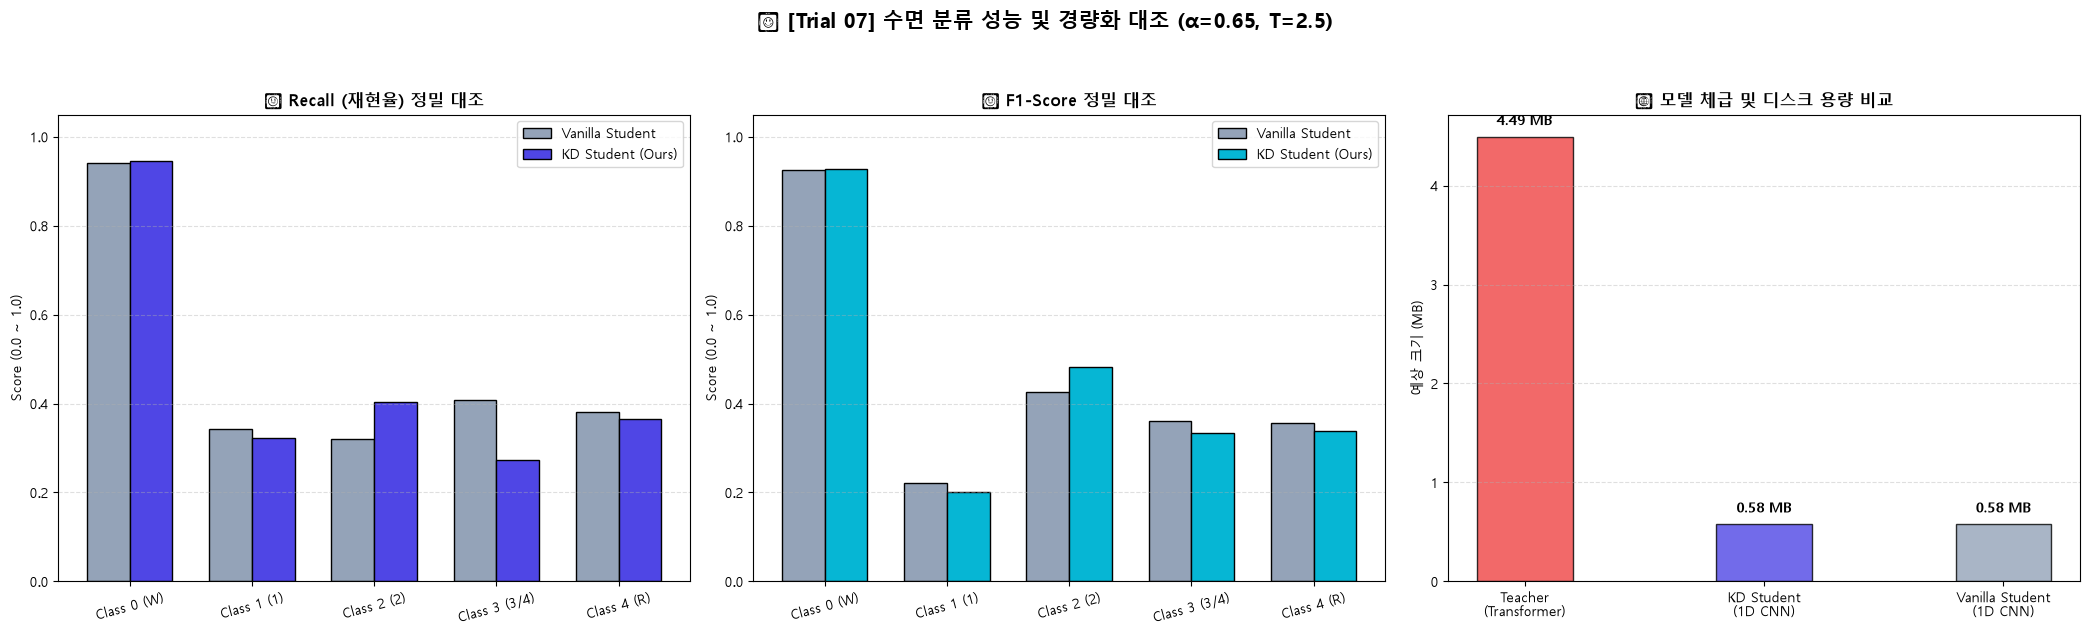

In [ ]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def get_latest_checkpoint(target_dir, prefix):
    if not os.path.exists(target_dir):
        return None
    search_pattern = os.path.join(target_dir, f"{prefix}*.pth")
    files = glob.glob(search_pattern)
    if not files:
        return None
    return max(files, key=os.path.getmtime)

KD_DIR = BASE_DIR
VANILLA_DIR = SAVE_DIR_VANILLA

AUTO_KD_PATH = get_latest_checkpoint(KD_DIR, prefix="student_")
AUTO_VANILLA_PATH = get_latest_checkpoint(VANILLA_DIR, prefix="vanilla_student_")

test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

teacher_model_obj = PurePyTorchTransformer()
kd_student = SleepStudentCNN(in_channels=2).to(device)
vanilla_student = SleepStudentCNN(in_channels=2).to(device)

kd_checkpoint = torch.load(AUTO_KD_PATH, map_location=device, weights_only=False)
vanilla_checkpoint = torch.load(AUTO_VANILLA_PATH, map_location=device, weights_only=False)

kd_student.load_state_dict(kd_checkpoint['model_state_dict'])
vanilla_student.load_state_dict(vanilla_checkpoint['model_state_dict'])

kd_student.eval()
vanilla_student.eval()

true_labels = []
kd_preds = []
vanilla_preds = []

with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(device, non_blocking=True)
        student_inputs = signals[:, [0, 3], :]

        kd_out = kd_student(student_inputs)
        vanilla_out = vanilla_student(student_inputs)

        true_labels.extend(labels.numpy())
        kd_preds.extend(kd_out.argmax(dim=1).cpu().numpy())
        vanilla_preds.extend(vanilla_out.argmax(dim=1).cpu().numpy())

kd_report = classification_report(true_labels, kd_preds, output_dict=True)
vanilla_report = classification_report(true_labels, vanilla_preds, output_dict=True)

classes = ['Class 0 (W)', 'Class 1 (1)', 'Class 2 (2)', 'Class 3 (3/4)', 'Class 4 (R)']
x_cls = np.arange(len(classes))
width = 0.35

kd_recalls = [kd_report[str(i)]['recall'] for i in range(5)]
vanilla_recalls = [vanilla_report[str(i)]['recall'] for i in range(5)]
kd_f1s = [kd_report[str(i)]['f1-score'] for i in range(5)]
vanilla_f1s = [vanilla_report[str(i)]['f1-score'] for i in range(5)]

def get_model_size_mb(model):
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return (params * 4) / (1024 * 1024)

teacher_size_mb = get_model_size_mb(teacher_model_obj)
student_size_mb = get_model_size_mb(kd_student)
compression_ratio = teacher_size_mb / student_size_mb

# -------------------------------------------------------------------------
# 📝 [하이퍼파라미터 포함] TXT 보고서 세션 구축
# -------------------------------------------------------------------------
REPORT_TXT_PATH = os.path.join(BASE_DIR, f"evaluation_report_trial{TRIAL_NUM:02d}.txt")

# 메모리 상 변수 안전 로드 (없을 경우 기본값 표기)
curr_alpha = alpha if 'alpha' in locals() else 0.7
curr_temp = temperature if 'temperature' in locals() else 3.0
curr_epochs = epochs if 'epochs' in locals() else 20
curr_batch = batch_size if 'batch_size' in locals() else 256

report_lines = [
    "=========================================================",
    f"        📊 Sleep-EDF Trial {TRIAL_NUM:02d} 최종 평가 상세 성적표",
    "=========================================================\n",
    f"📌 [로드된 KD 모델 파일] : {AUTO_KD_PATH}",
    f"📌 [로드된 바닐라 파일] : {AUTO_VANILLA_PATH}\n",
    "---------------------------------------------------------",
    "⚙️ 주요 학습 하이퍼파라미터 (Hyperparameters)",
    "---------------------------------------------------------",
    f"- Alpha (Hard/Soft 손실 비중) : {curr_alpha} (Hard Loss: {curr_alpha:.2f} | Soft Loss: {1.0 - curr_alpha:.2f})",
    f"- Temperature (소프트맥스 온도): {curr_temp}",
    f"- Epochs (학습 에폭 수)       : {curr_epochs}",
    f"- Batch Size (배치 크기)       : {curr_batch}",
    f"- Input Spec (입력 신호)       : 2-CH (Channel 0: Fpz-Cz + Channel 3: EMG)\n",
    "---------------------------------------------------------",
    "1. 모델 용량 및 경량화율",
    "---------------------------------------------------------",
    f"- 교사 모델 (Transformer) : {teacher_size_mb:.2f} MB",
    f"- 학생 모델 (1D CNN)     : {student_size_mb:.2f} MB",
    f"- 용량 압축 비율          : 약 {compression_ratio:.1f}배 압축 완료\n",
    "---------------------------------------------------------",
    "2. 클래스별 Recall (재현율) 대조",
    "---------------------------------------------------------"
]

for idx, cls_name in enumerate(classes):
    report_lines.append(f"- {cls_name:15s} | 바닐라: {vanilla_recalls[idx]:.4f} | KD: {kd_recalls[idx]:.4f}")

report_lines.append("\n---------------------------------------------------------")
report_lines.append("3. 클래스별 F1-Score 대조")
report_lines.append("---------------------------------------------------------")
for idx, cls_name in enumerate(classes):
    report_lines.append(f"- {cls_name:15s} | 바닐라: {vanilla_f1s[idx]:.4f} | KD: {kd_f1s[idx]:.4f}")

report_lines.append("\n---------------------------------------------------------")
report_lines.append("4. 전체 Classification Report (상세)")
report_lines.append("---------------------------------------------------------")
report_lines.append("\n[KD Student Model]")
report_lines.append(classification_report(true_labels, kd_preds, target_names=classes))
report_lines.append("\n[Vanilla Student Model]")
report_lines.append(classification_report(true_labels, vanilla_preds, target_names=classes))

with open(REPORT_TXT_PATH, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print(f"📝 [저장 완료] 하이퍼파라미터가 명시된 성적표 TXT 저장 완료 ➡️ {REPORT_TXT_PATH}")

# 시각화 대시보드
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

axes[0].bar(x_cls - width/2, vanilla_recalls, width, label='Vanilla Student', color='#94a3b8', edgecolor='black')
axes[0].bar(x_cls + width/2, kd_recalls, width, label='KD Student (Ours)', color='#4f46e5', edgecolor='black')
axes[0].set_title('🥇 Recall (재현율) 정밀 대조', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_cls)
axes[0].set_xticklabels(classes, rotation=15)
axes[0].set_ylabel('Score (0.0 ~ 1.0)')
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].legend()

axes[1].bar(x_cls - width/2, vanilla_f1s, width, label='Vanilla Student', color='#94a3b8', edgecolor='black')
axes[1].bar(x_cls + width/2, kd_f1s, width, label='KD Student (Ours)', color='#06b6d4', edgecolor='black')
axes[1].set_title('🥇 F1-Score 정밀 대조', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_cls)
axes[1].set_xticklabels(classes, rotation=15)
axes[1].set_ylabel('Score (0.0 ~ 1.0)')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].legend()

models_label = ['Teacher\n(Transformer)', 'KD Student\n(1D CNN)', 'Vanilla Student\n(1D CNN)']
file_sizes = [teacher_size_mb, student_size_mb, student_size_mb]
bars = axes[2].bar(models_label, file_sizes, color=['#ef4444', '#4f46e5', '#94a3b8'], edgecolor='black', alpha=0.8, width=0.4)
axes[2].set_title('💾 모델 체급 및 디스크 용량 비교', fontsize=12, fontweight='bold')
axes[2].set_ylabel('예상 크기 (MB)')
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, yval + (teacher_size_mb * 0.02), f"{yval:.2f} MB", ha='center', va='bottom', fontweight='bold')

plt.suptitle(f"⚡ [Trial {TRIAL_NUM:02d}] 수면 분류 성능 및 경량화 대조 (α={curr_alpha}, T={curr_temp})", fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()